In [ ]:
from google.colab import files
uploaded=files.upload()

Saving cardio_train.csv to cardio_train.csv


In [ ]:
import pandas as pd
df=pd.read_csv("cardio_train.csv",sep=";")
df.drop("id", axis=1, inplace=True)
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0


In [ ]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


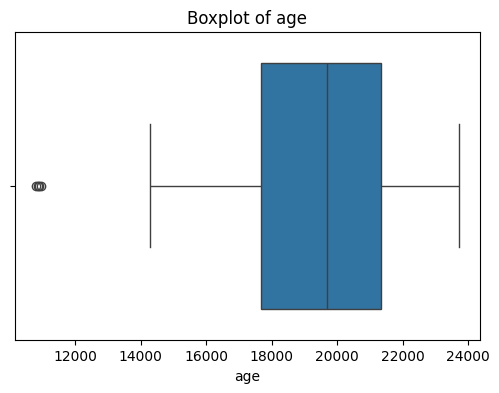

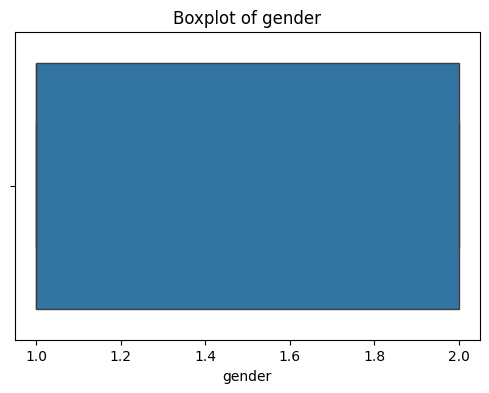

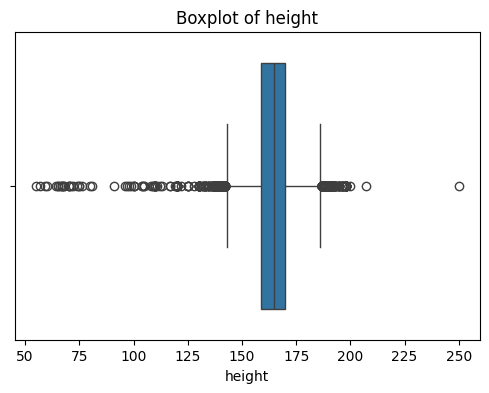

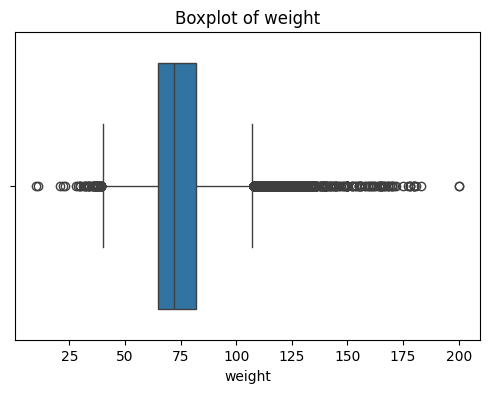

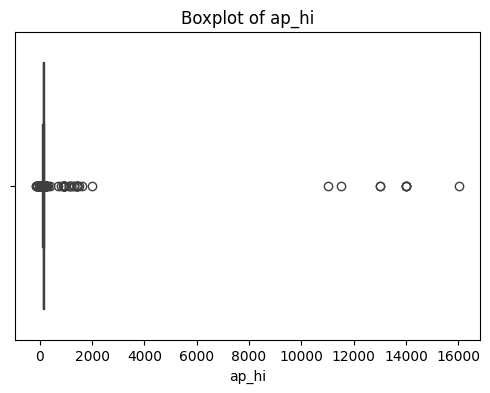

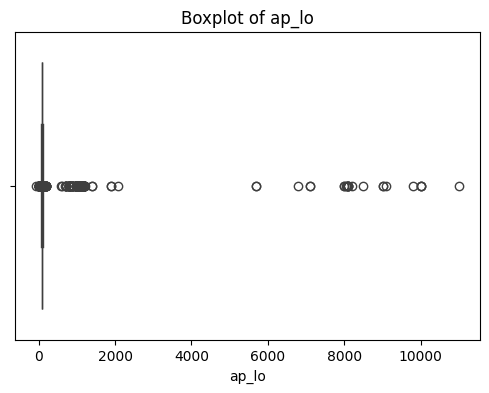

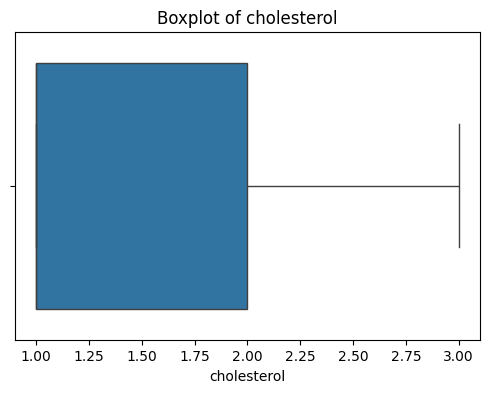

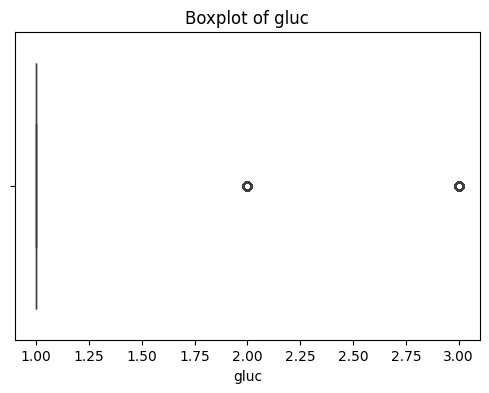

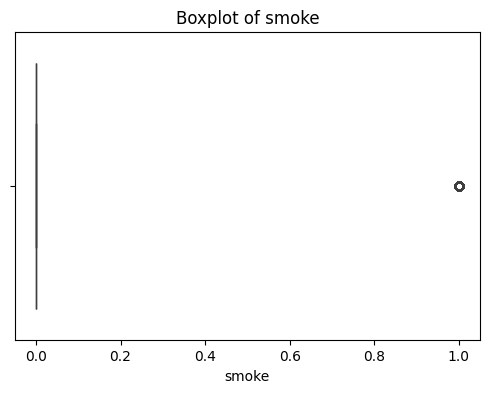

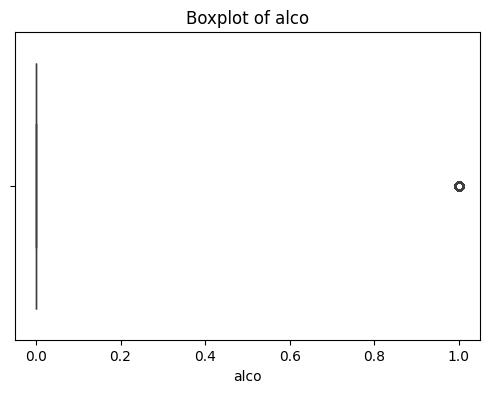

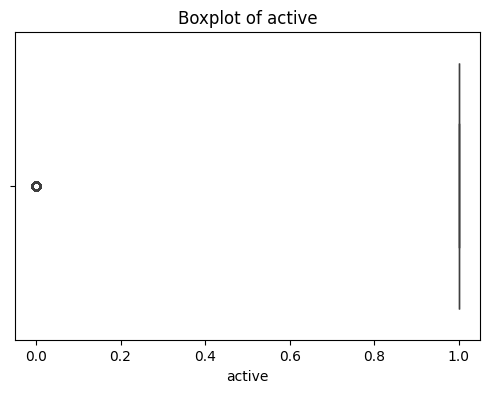

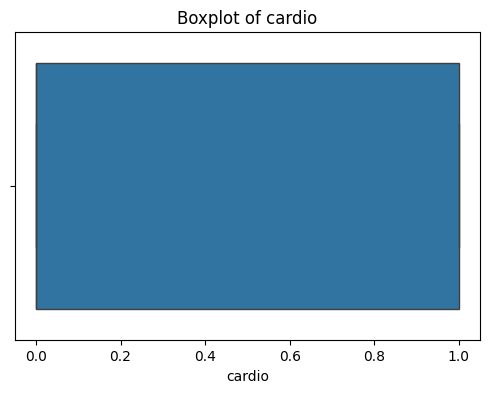

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [ ]:
# Remove unrealistic values
df = df[(df["ap_hi"] > 60) & (df["ap_hi"] < 250)]
df = df[(df["ap_lo"] > 40) & (df["ap_lo"] < 150)]
df = df[(df["height"] > 100) & (df["height"] < 220)]
df = df[(df["weight"] > 30) & (df["weight"] < 200)]

# Remove inconsistent BP
df = df[df["ap_hi"] > df["ap_lo"]]

# Remove duplicates
df.drop_duplicates(inplace=True)

df['age_years'] = (df['age'] / 365).round().astype(int)
df.drop(columns=['age'], inplace=True)
df['height'] = df['height'] / 100

df['bmi'] = df['weight'] / (df['height'] ** 2)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['map'] = df['ap_lo'] + (df['ap_hi'] - df['ap_lo']) / 3

df = df[(df["bmi"] > 10) & (df["bmi"] < 60)]

df['cholesterol_gluc_interaction'] = (
    df['cholesterol'] * df['gluc']
)
def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    elif bmi < 30:
        return 2
    elif bmi < 35:
        return 3
    elif bmi < 40:
        return 4
    else:
        return 5

df["bmi_category"] = df["bmi"].apply(bmi_category)

def map_category(x):
    if x < 70:
        return 0
    elif x < 80:
        return 1
    elif x < 90:
        return 2
    elif x < 100:
        return 3
    elif x < 110:
        return 4
    else:
        return 5

df["map_category"] = df["map"].apply(map_category)

def age_category(age):
    if age < 40:
        return 0
    elif age < 45:
        return 1
    elif age < 50:
        return 2
    elif age < 55:
        return 3
    elif age < 60:
        return 4
    elif age < 65:
        return 5
    else:
        return 6

df["age_category"] = df["age_years"].apply(age_category)

def bp_category(row):

    ap_hi = row["ap_hi"]
    ap_lo = row["ap_lo"]

    if ap_hi < 120 and ap_lo < 80:
        return 0
    elif 120 <= ap_hi < 130 and ap_lo < 80:
        return 1
    elif (130 <= ap_hi < 140) or (80 <= ap_lo < 90):
        return 2
    elif (140 <= ap_hi < 180) or (90 <= ap_lo < 120):
        return 3
    else:
        return 4

df["bp_category"] = df.apply(bp_category, axis=1)

columns = [
    "height",
    "weight",
    "bmi",
    "map",
    "pulse_pressure"
]

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

df.reset_index(drop=True, inplace=True)
print(df.shape)

(56964, 20)


In [ ]:
print(df.shape)

(56964, 20)


In [ ]:
print(df.columns)

Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi',
       'pulse_pressure', 'map', 'cholesterol_gluc_interaction', 'bmi_category',
       'map_category', 'age_category', 'bp_category'],
      dtype='object')


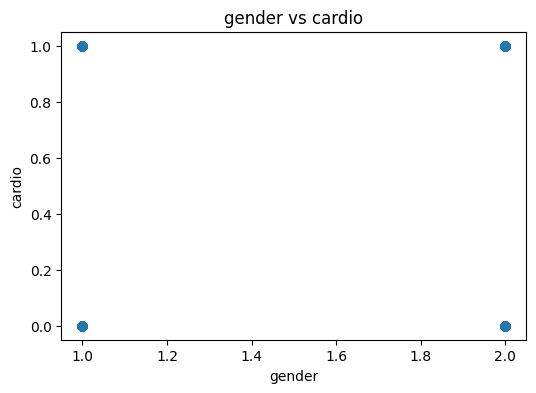

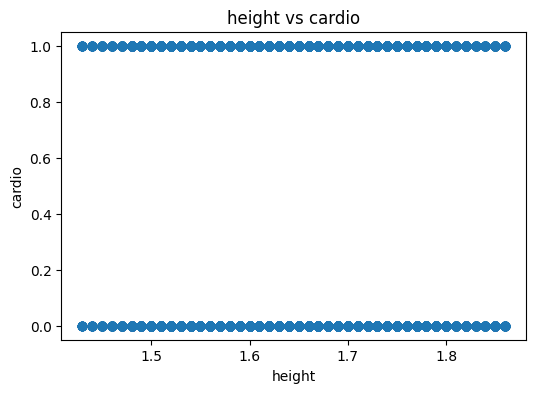

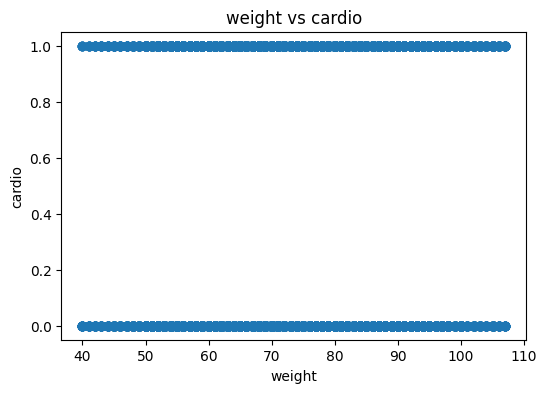

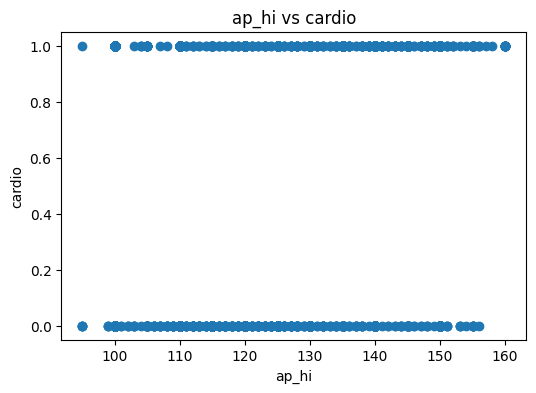

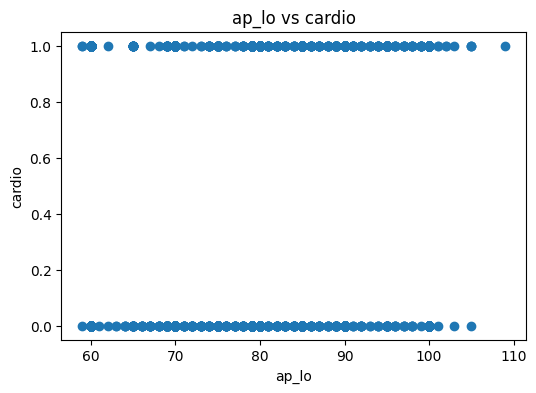

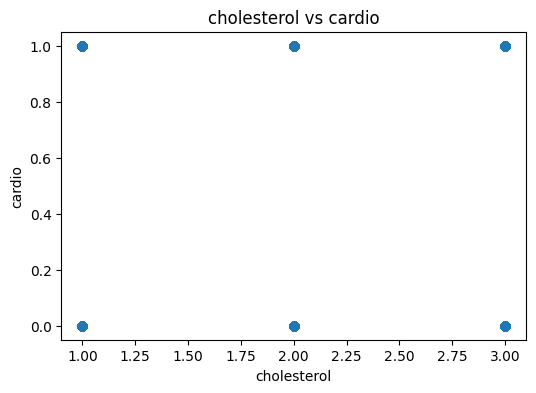

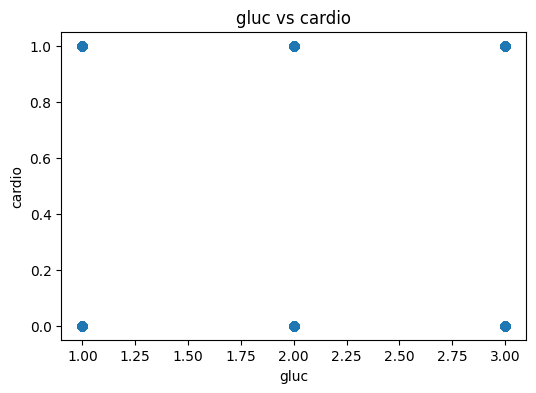

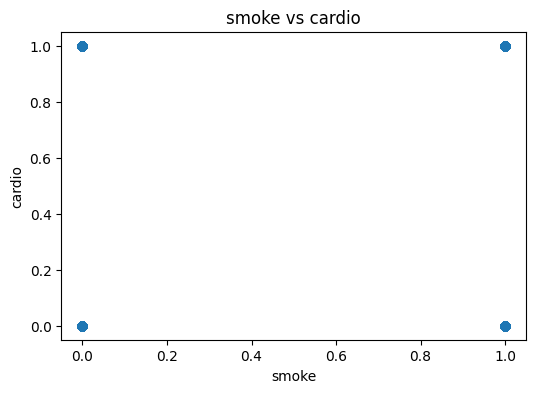

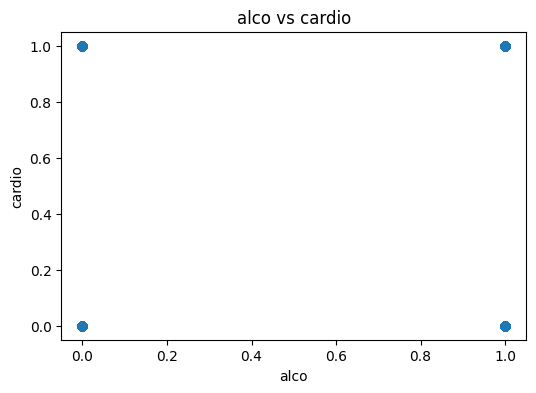

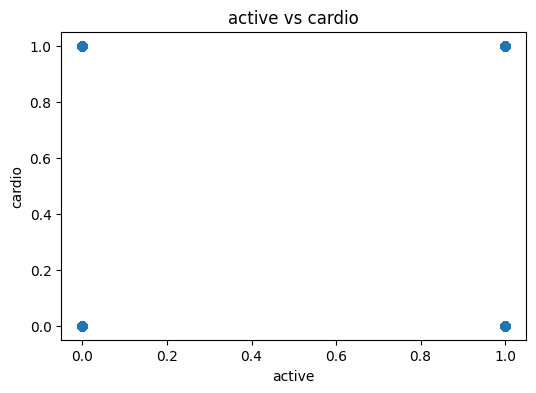

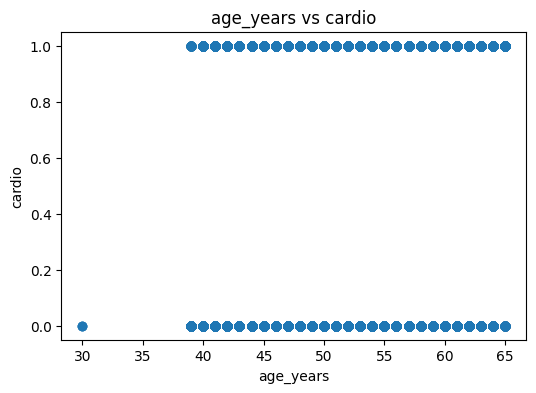

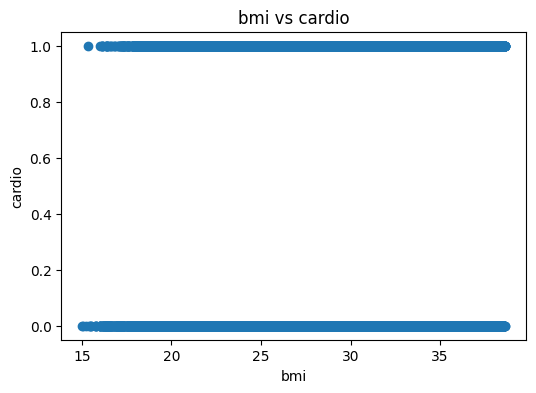

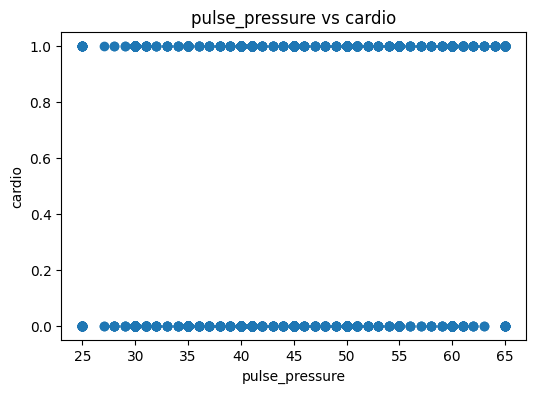

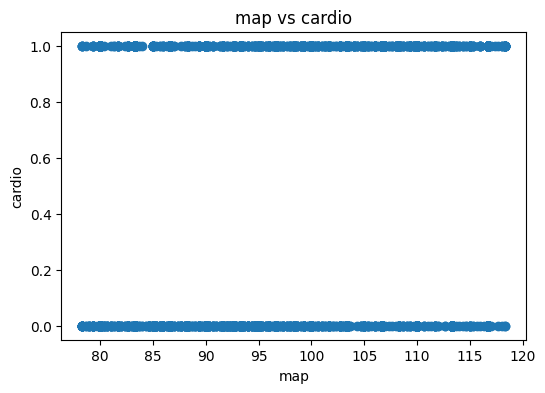

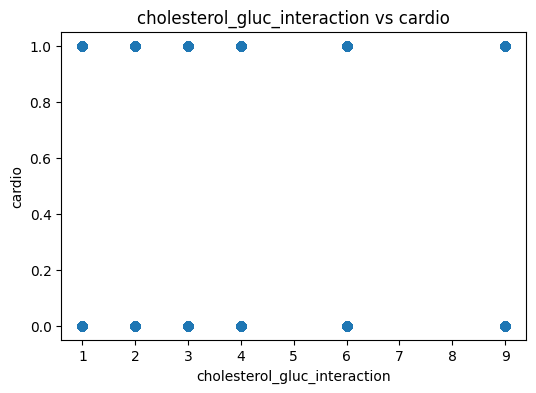

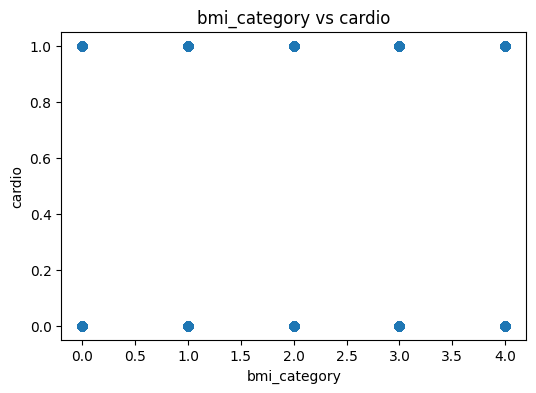

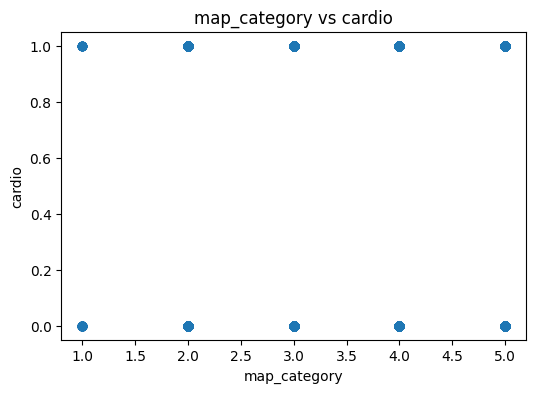

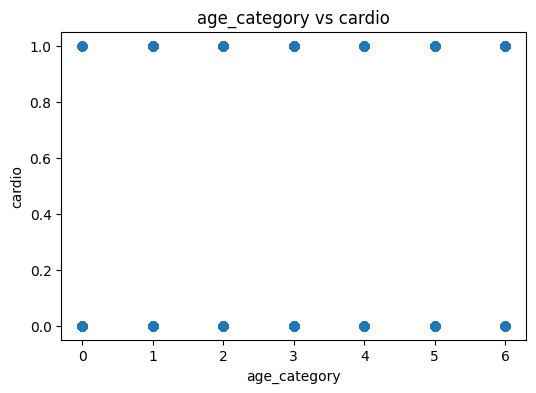

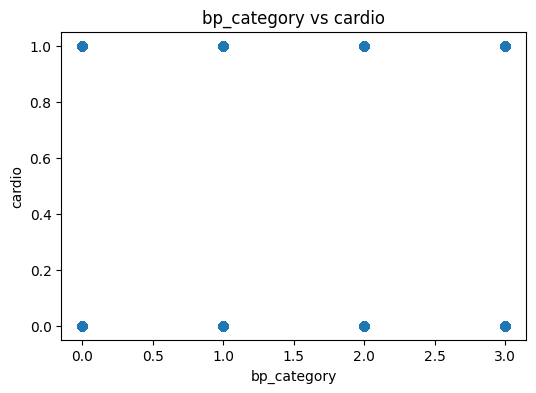

In [ ]:
import matplotlib.pyplot as plt

features = df.columns.drop(["cardio"])

for col in features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df["cardio"])
    plt.xlabel(col)
    plt.ylabel("cardio")
    plt.title(f"{col} vs cardio")
    plt.show()

In [ ]:
print(df["cardio"].value_counts(normalize=True))

cardio
0    0.532038
1    0.467962
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
X = df[columns]
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (45571, 5), X_test: (11393, 5)


In [ ]:
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Features and target
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Base model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter Grid
param_grid = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best Model
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

# Prediction
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Test Metrics
print("Accuracy  :", round(accuracy_score(y_test, y_pred), 4))
print("Precision :", round(precision_score(y_test, y_pred), 4))
print("Recall    :", round(recall_score(y_test, y_pred), 4))
print("F1 Score  :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC   :", round(roc_auc_score(y_test, y_prob), 4))

# Cross Validation
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    best_model,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("CV Accuracy :", round(cv_results["test_accuracy"].mean(), 4))
print("CV Precision:", round(cv_results["test_precision"].mean(), 4))
print("CV Recall   :", round(cv_results["test_recall"].mean(), 4))
print("CV F1 Score :", round(cv_results["test_f1"].mean(), 4))
print("CV ROC AUC  :", round(cv_results["test_roc_auc"].mean(), 4))

Best Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy  : 0.7168
Precision : 0.76
Recall    : 0.5728
F1 Score  : 0.6533
ROC AUC   : 0.7729
CV Accuracy : 0.7155
CV Precision: 0.7505
CV Recall   : 0.589
CV F1 Score : 0.6594
CV ROC AUC  : 0.7735


In [ ]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Features and target
X = df.drop(columns=["cardio"])
y = df["cardio"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=100
)

# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Prediction
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Test Metrics
print("Accuracy  :", round(accuracy_score(y_test, y_pred), 4))
print("Precision :", round(precision_score(y_test, y_pred), 4))
print("Recall    :", round(recall_score(y_test, y_pred), 4))
print("F1 Score  :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC   :", round(roc_auc_score(y_test, y_prob), 4))

# Cross Validation
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    rf,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("CV Accuracy :", round(cv_results["test_accuracy"].mean(), 4))
print("CV Precision:", round(cv_results["test_precision"].mean(), 4))
print("CV Recall   :", round(cv_results["test_recall"].mean(), 4))
print("CV F1 Score :", round(cv_results["test_f1"].mean(), 4))
print("CV ROC AUC  :", round(cv_results["test_roc_auc"].mean(), 4))

Accuracy  : 0.7194
Precision : 0.7178
Recall    : 0.6546
F1 Score  : 0.6847
ROC AUC   : 0.7848
CV Accuracy : 0.7193
CV Precision: 0.7167
CV Recall   : 0.6617
CV F1 Score : 0.6881
CV ROC AUC  : 0.7822


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ===========================
# Features and Target
# ===========================
X = df.drop(columns=["cardio"])
y = df["cardio"]

# ===========================
# Train-Test Split
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===========================
# XGBoost with Early Stopping
# ===========================
xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    early_stopping_rounds=50
)

xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Best Iteration:", xgb.best_iteration)

# ===========================
# Prediction
# ===========================
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("Accuracy  :", round(accuracy_score(y_test, y_pred), 4))
print("Precision :", round(precision_score(y_test, y_pred), 4))
print("Recall    :", round(recall_score(y_test, y_pred), 4))
print("F1 Score  :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC   :", round(roc_auc_score(y_test, y_prob), 4))

# =====================================================
# New Model WITHOUT Early Stopping for Cross Validation
# =====================================================

xgb_cv = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    xgb_cv,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("\n===== Cross Validation =====")
print("CV Accuracy :", round(cv_results["test_accuracy"].mean(), 4))
print("CV Precision:", round(cv_results["test_precision"].mean(), 4))
print("CV Recall   :", round(cv_results["test_recall"].mean(), 4))
print("CV F1 Score :", round(cv_results["test_f1"].mean(), 4))
print("CV ROC AUC  :", round(cv_results["test_roc_auc"].mean(), 4))

Best Iteration: 93
Accuracy  : 0.7198
Precision : 0.7251
Recall    : 0.6462
F1 Score  : 0.6834
ROC AUC   : 0.7846

===== Cross Validation =====
CV Accuracy : 0.7158
CV Precision: 0.7241
CV Recall   : 0.6344
CV F1 Score : 0.6763
CV ROC AUC  : 0.7766


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# Define features and target
X = df.drop(columns=['cardio'])
y = df["cardio"]
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100
)
# Random Forest model
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
# Train
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
# ---- CROSS VALIDATION ----
scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Accuracy: 0.7193890985692969
Cross-validation scores: [0.71684368 0.72649873 0.71640481 0.72017906 0.71637992]
Average CV score: 0.7192612372494642


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Shared Setup — FT-Transformer, TabTransformer, Saint
# ══════════════════════════════════════════════════════════════════
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

# ── Feature Columns ───────────────────────────────────────────────
CONTINUOUS_COLS = [
    'age_years', 'height', 'weight', 'ap_hi', 'ap_lo',
    'bmi', 'pulse_pressure', 'map', 'cholesterol_gluc_interaction'
]

CATEGORICAL_COLS = [
    'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active',
    'bmi_category', 'map_category', 'age_category', 'bp_category'
]

X_cont_raw = df[CONTINUOUS_COLS].values.astype(np.float32)
X_cat_raw  = df[CATEGORICAL_COLS].values.astype(np.int64)
y_raw      = df["cardio"].values.astype(np.float32)

# ── Scale continuous ──────────────────────────────────────────────
scaler     = StandardScaler()
X_cont_raw = scaler.fit_transform(X_cont_raw)

# ── Train / Test Split ────────────────────────────────────────────
(X_cont_tr, X_cont_te,
 X_cat_tr,  X_cat_te,
 y_tr,      y_te) = train_test_split(
    X_cont_raw, X_cat_raw, y_raw,
    test_size=0.2, random_state=42, stratify=y_raw
)

# ── DataLoader helper ─────────────────────────────────────────────
def make_loader(Xc, Xk, y, batch_size=256, shuffle=True):
    ds = TensorDataset(
        torch.tensor(Xc),
        torch.tensor(Xk),
        torch.tensor(y)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_cont_tr, X_cat_tr, y_tr, shuffle=True)
test_loader  = make_loader(X_cont_te, X_cat_te, y_te, shuffle=False)

# ── Dimensions ────────────────────────────────────────────────────
CAT_DIMS      = [int(df[c].max()) + 1 for c in CATEGORICAL_COLS]
NUM_CONT      = len(CONTINUOUS_COLS)
NUM_CAT       = len(CATEGORICAL_COLS)
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)
print("Train  :", X_cont_tr.shape, X_cat_tr.shape)
print("Test   :", X_cont_te.shape, X_cat_te.shape)

# ── Shared evaluation function ────────────────────────────────────
def evaluate(model, loader, model_type="tab"):
    model.eval()
    probs_all, preds_all, true_all = [], [], []
    with torch.no_grad():
        for Xc, Xk, yb in loader:
            Xc, Xk = Xc.to(device), Xk.to(device)
            if model_type == "ft":
                logits = model(Xc, Xk)
            else:
                logits = model(Xc, Xk)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            probs_all.extend(probs)
            preds_all.extend(preds)
            true_all.extend(yb.numpy())
    return true_all, preds_all, probs_all

def print_metrics(name, true, preds, probs):
    print(f"\n{'='*10} {name} {'='*10}")
    print("Accuracy :", round(accuracy_score(true, preds), 4))
    print("Precision:", round(precision_score(true, preds), 4))
    print("Recall   :", round(recall_score(true, preds), 4))
    print("F1 Score :", round(f1_score(true, preds), 4))
    print("ROC AUC  :", round(roc_auc_score(true, probs), 4))

# ── Shared training loop ──────────────────────────────────────────
def train_model(model, loader, epochs=30, lr=1e-3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    for epoch in range(1, epochs + 1):
        model.train()
        total = 0
        for Xc, Xk, yb in loader:
            Xc, Xk, yb = Xc.to(device), Xk.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xc, Xk), yb)
            loss.backward()
            optimizer.step()
            total += loss.item()
        avg = total / len(loader)
        scheduler.step(avg)
        if epoch % 5 == 0:
            print(f"  Epoch {epoch:02d} | Loss: {avg:.4f}")
    return model

print("\nShared setup complete.")


Device : cuda
Train  : (45571, 9) (45571, 10)
Test   : (11393, 9) (11393, 10)

Shared setup complete.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# TabTransformer
# ══════════════════════════════════════════════════════════════════

class TabTransformer(nn.Module):
    """
    Categorical features → Embedding → Transformer Encoder
    Continuous features  → StandardScaler (already done)
    Both concatenated    → MLP head
    Paper: Huang et al. 2020 (https://arxiv.org/abs/2012.06678)
    """
    def __init__(self, cat_dims, num_continuous,
                 embed_dim=32, n_heads=8, n_layers=6,
                 ff_dim=128, dropout=0.1):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(d, embed_dim) for d in cat_dims
        ])
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        mlp_in = len(cat_dims) * embed_dim + num_continuous
        self.mlp = nn.Sequential(
            nn.Linear(mlp_in, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x_cont, x_cat):
        emb = torch.stack([e(x_cat[:, i]) for i, e in enumerate(self.embeddings)], dim=1)
        out = self.transformer(emb).flatten(1)
        return self.mlp(torch.cat([out, x_cont], dim=1)).squeeze(1)

print("Training TabTransformer...")
tab_model = TabTransformer(CAT_DIMS, NUM_CONT).to(device)
tab_model = train_model(tab_model, train_loader, epochs=30)

true, preds, probs = evaluate(tab_model, test_loader)
print_metrics("TabTransformer", true, preds, probs)


Training TabTransformer...
  Epoch 05 | Loss: 0.5605
  Epoch 10 | Loss: 0.5562
  Epoch 15 | Loss: 0.5581
  Epoch 20 | Loss: 0.5552
  Epoch 25 | Loss: 0.5554
  Epoch 30 | Loss: 0.5517

========== TabTransformer ==========
Accuracy : 0.7174
Precision: 0.7205
Recall   : 0.647
F1 Score : 0.6818
ROC AUC  : 0.7825


In [ ]:
# ══════════════════════════════════════════════════════════════════
# FT-Transformer  (Feature Tokenizer + Transformer)
# ══════════════════════════════════════════════════════════════════

class FeatureTokenizer(nn.Module):
    """
    Converts every feature (both continuous and categorical) into
    a token of size embed_dim, so the Transformer sees ALL features.
    Paper: Gorishniy et al. 2021 (https://arxiv.org/abs/2106.11959)
    """
    def __init__(self, cat_dims, num_continuous, embed_dim=32):
        super().__init__()
        # Categorical: one embedding per column
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(d, embed_dim) for d in cat_dims
        ])
        # Continuous: linear projection per feature  (weight + bias token)
        self.cont_weight = nn.Parameter(torch.randn(num_continuous, embed_dim))
        self.cont_bias   = nn.Parameter(torch.zeros(num_continuous, embed_dim))

    def forward(self, x_cont, x_cat):
        # Cat tokens: (B, n_cat, embed_dim)
        cat_tokens  = torch.stack(
            [e(x_cat[:, i]) for i, e in enumerate(self.cat_embeddings)], dim=1
        )
        # Cont tokens: (B, n_cont, embed_dim)
        cont_tokens = x_cont.unsqueeze(-1) * self.cont_weight.unsqueeze(0) + self.cont_bias.unsqueeze(0)
        # All tokens together: (B, n_cat + n_cont, embed_dim)
        return torch.cat([cat_tokens, cont_tokens], dim=1)


class FTTransformer(nn.Module):
    def __init__(self, cat_dims, num_continuous,
                 embed_dim=32, n_heads=8, n_layers=3,
                 ff_dim=128, dropout=0.1):
        super().__init__()
        self.tokenizer = FeatureTokenizer(cat_dims, num_continuous, embed_dim)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        n_tokens = len(cat_dims) + num_continuous
        self.head = nn.Sequential(
            nn.LayerNorm(n_tokens * embed_dim),
            nn.Linear(n_tokens * embed_dim, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x_cont, x_cat):
        tokens = self.tokenizer(x_cont, x_cat)          # (B, n_tokens, d)
        out    = self.transformer(tokens).flatten(1)     # (B, n_tokens*d)
        return self.head(out).squeeze(1)

print("Training FT-Transformer...")
ft_model = FTTransformer(CAT_DIMS, NUM_CONT).to(device)
ft_model = train_model(ft_model, train_loader, epochs=30)

true, preds, probs = evaluate(ft_model, test_loader)
print_metrics("FT-Transformer", true, preds, probs)


Training FT-Transformer...
  Epoch 05 | Loss: 0.5574
  Epoch 10 | Loss: 0.5563
  Epoch 15 | Loss: 0.5572
  Epoch 20 | Loss: 0.5563
  Epoch 25 | Loss: 0.5523
  Epoch 30 | Loss: 0.5511

========== FT-Transformer ==========
Accuracy : 0.719
Precision: 0.7215
Recall   : 0.6503
F1 Score : 0.6841
ROC AUC  : 0.7831


In [ ]:
# ══════════════════════════════════════════════════════════════════
# SAINT  (Self-Attention and Intersample Attention Transformer)
# ══════════════════════════════════════════════════════════════════


class SAINTLayer(nn.Module):
    """One SAINT block: column self-attention + inter-sample attention."""
    def __init__(self, embed_dim, n_heads, ff_dim, dropout):
        super().__init__()
        # Column (intra-sample) self-attention
        self.col_attn = nn.MultiheadAttention(embed_dim, n_heads,
                                               dropout=dropout, batch_first=True)
        self.col_ff   = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, ff_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim)
        )
        self.col_norm1 = nn.LayerNorm(embed_dim)
        self.col_norm2 = nn.LayerNorm(embed_dim)

        # Inter-sample attention  (operates on flattened row vectors)
        self.row_norm1  = nn.LayerNorm(embed_dim)
        self.row_norm2  = nn.LayerNorm(embed_dim)
        self.inter_attn = nn.MultiheadAttention(embed_dim, n_heads,
                                                 dropout=dropout, batch_first=True)
        self.inter_ff   = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, ff_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim)
        )

    def forward(self, x):
        # x: (B, n_tokens, embed_dim)
        # 1. Column self-attention
        attn_out, _ = self.col_attn(x, x, x)
        x = self.col_norm1(x + attn_out)
        x = self.col_norm2(x + self.col_ff(x))

        # 2. Inter-sample attention
        # Treat each token position independently across the batch
        # Transpose to (n_tokens, B, embed_dim) → attend over B
        xt = x.permute(1, 0, 2)                    # (n_tokens, B, d)
        attn_out2, _ = self.inter_attn(xt, xt, xt) # (n_tokens, B, d)
        xt = self.row_norm1(xt + attn_out2)
        xt = self.row_norm2(xt + self.inter_ff(xt))
        x  = xt.permute(1, 0, 2)                   # back to (B, n_tokens, d)
        return x


class SAINT(nn.Module):
    def __init__(self, cat_dims, num_continuous,
                 embed_dim=32, n_heads=8, n_layers=3,
                 ff_dim=128, dropout=0.1):
        super().__init__()
        # Same feature tokenizer as FT-Transformer
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(d, embed_dim) for d in cat_dims
        ])
        self.cont_weight = nn.Parameter(torch.randn(num_continuous, embed_dim))
        self.cont_bias   = nn.Parameter(torch.zeros(num_continuous, embed_dim))

        self.layers = nn.ModuleList([
            SAINTLayer(embed_dim, n_heads, ff_dim, dropout)
            for _ in range(n_layers)
        ])

        n_tokens = len(cat_dims) + num_continuous
        self.head = nn.Sequential(
            nn.LayerNorm(n_tokens * embed_dim),
            nn.Linear(n_tokens * embed_dim, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x_cont, x_cat):
        # Tokenize
        cat_tok  = torch.stack(
            [e(x_cat[:, i]) for i, e in enumerate(self.cat_embeddings)], dim=1
        )
        cont_tok = x_cont.unsqueeze(-1) * self.cont_weight + self.cont_bias
        x = torch.cat([cat_tok, cont_tok], dim=1)   # (B, n_tokens, d)

        for layer in self.layers:
            x = layer(x)

        return self.head(x.flatten(1)).squeeze(1)

print("Training SAINT...")
saint_model = SAINT(CAT_DIMS, NUM_CONT).to(device)
saint_model = train_model(saint_model, train_loader, epochs=30)

true, preds, probs = evaluate(saint_model, test_loader)
print_metrics("SAINT", true, preds, probs)


Training SAINT...
  Epoch 05 | Loss: 0.5587
  Epoch 10 | Loss: 0.5553
  Epoch 15 | Loss: 0.5529
  Epoch 20 | Loss: 0.5506
  Epoch 25 | Loss: 0.5495
  Epoch 30 | Loss: 0.5494

========== SAINT ==========
Accuracy : 0.7157
Precision: 0.7282
Recall   : 0.6261
F1 Score : 0.6733
ROC AUC  : 0.7811


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Comparison — TabTransformer vs FT-Transformer vs SAINT
# ══════════════════════════════════════════════════════════════════
import pandas as pd

def get_metrics(model, loader):
    true, preds, probs = evaluate(model, loader)
    return {
        "Accuracy":  round(accuracy_score(true, preds), 4),
        "Precision": round(precision_score(true, preds), 4),
        "Recall":    round(recall_score(true, preds), 4),
        "F1":        round(f1_score(true, preds), 4),
        "ROC AUC":   round(roc_auc_score(true, probs), 4),
    }

results = {
    "TabTransformer": get_metrics(tab_model,   test_loader),
    "FT-Transformer": get_metrics(ft_model,    test_loader),
    "SAINT":          get_metrics(saint_model, test_loader),
}

comparison_df = pd.DataFrame(results).T
print(comparison_df.to_string())


                Accuracy  Precision  Recall      F1  ROC AUC
TabTransformer    0.7174     0.7205  0.6470  0.6818   0.7825
FT-Transformer    0.7190     0.7215  0.6503  0.6841   0.7831
SAINT             0.7157     0.7282  0.6261  0.6733   0.7811
